# Train Experimental Dashboard Models

Trains and persists the 3 experimental models shown on the dashboard's EXPERIMENTAL panel, separate from the deployed hybrid detector:

1. **XGBoost, single-flow only** - 8 base features, no temporal context
2. **XGBoost, single-flow + temporal features** - adds rolling-window stats over prior flows grouped by `(Dst Port, Protocol)`
3. **CNN+LSTM, raw sequence** - a 10-step raw sequence over the same grouping

Data: 10 days of CIC-IDS2018 - 7 partial samples already in `data/cicids2018/` plus 3 full days (`02-28`, `03-01`, `03-02`) in `data/cicids2018_full/` that add Infiltration and Botnet attack types not present in the original 7.

Run this from the `Adaptive-IDS-with-XAI` project root (so the relative data/model paths resolve), with a Python environment that has `torch` installed - CUDA build recommended if you have an NVIDIA GPU, for a much faster variant 3.

In [1]:
import json
import pickle
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PARTIAL_DIR = PROJECT_ROOT / "data" / "cicids2018"
PARTIAL_DAYS = [
    "02-14-2018.csv", "02-15-2018.csv", "02-16-2018.csv", "02-20-2018.csv",
    "02-21-2018.csv", "02-22-2018.csv", "02-23-2018.csv",
]

FULL_DIR = PROJECT_ROOT / "data" / "cicids2018_full"
FULL_DAYS = ["02-28-2018.csv", "03-01-2018.csv", "03-02-2018.csv"]

OUT_DIR = PROJECT_ROOT / "models" / "experimental"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEQUENCE_LENGTH = 10
BASE_FEATURES = [
    "Flow Duration", "Tot Fwd Pkts", "TotLen Fwd Pkts",
    "Flow Byts/s", "Flow Pkts/s", "Avg Pkt Size", "Min Pkt Size", "Protocol",
]
GROUP_KEYS = ["day", "Dst Port", "Protocol"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
  GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## Load and split each day

Per-day chronological split: cutoff at the 70th percentile of *that day's own attack timestamps* (attack bursts are only minutes wide in some days, so a naive whole-dataset time split can leave a day's test half with zero attacks). Every attack type ends up represented in both train and test - this tests "recognize more of an ongoing campaign", not zero-shot detection of an entirely new attack type.

In [2]:
def load_one_day(path):
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.strip()
    df = df[df["Label"] != "Label"].reset_index(drop=True)

    df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
    df = df.dropna(subset=["Timestamp"])
    df["Binary_Label"] = df["Label"].apply(lambda x: 0 if str(x).strip().lower() == "benign" else 1)

    for col in ["TotLen Fwd Pkts", "Tot Fwd Pkts", "Fwd Pkt Len Min", "Flow Duration",
                "Flow Byts/s", "Flow Pkts/s", "Protocol", "Dst Port"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["Avg Pkt Size"] = df["TotLen Fwd Pkts"] / df["Tot Fwd Pkts"].replace(0, 1)
    df["Min Pkt Size"] = df["Fwd Pkt Len Min"]

    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=BASE_FEATURES + ["Dst Port"])
    df["day"] = path.stem
    return df.sort_values("Timestamp").reset_index(drop=True)


def per_day_split(day_df):
    attacks = day_df.loc[day_df["Binary_Label"] == 1, "Timestamp"]
    if len(attacks) < 20:
        cutoff = day_df["Timestamp"].quantile(0.8)
    else:
        cutoff = attacks.quantile(0.7)
    train_mask = (day_df["Timestamp"] < cutoff).values
    return train_mask, ~train_mask


def build_dataset():
    frames = [load_one_day(PARTIAL_DIR / f) for f in PARTIAL_DAYS] + \
             [load_one_day(FULL_DIR / f) for f in FULL_DAYS]

    train_parts, test_parts = [], []
    for day_df in frames:
        tr, te = per_day_split(day_df)
        day_df = day_df.assign(is_test=te)
        train_parts.append(day_df[tr])
        test_parts.append(day_df[te])
        atk = day_df["Binary_Label"]
        print(f"  {day_df['day'].iloc[0]}: {len(day_df)} rows, "
              f"train={tr.sum()} (attack={atk[tr].sum()}), test={te.sum()} (attack={atk[te].sum()})")

    df = pd.concat(train_parts + test_parts, ignore_index=True)
    train_mask = np.concatenate([np.ones(len(p), dtype=bool) for p in train_parts] +
                                 [np.zeros(len(p), dtype=bool) for p in test_parts])
    return df, train_mask, ~train_mask


print("loading + splitting each day (10 days: 7 partial samples + 3 full new days) ...")
df, train_mask, test_mask = build_dataset()
print(f"\ncombined: {len(df)} rows  train={train_mask.sum()}  test={test_mask.sum()}")
print(f"train attack ratio: {df.loc[train_mask,'Binary_Label'].mean():.3f}")
print(f"test attack ratio:  {df.loc[test_mask,'Binary_Label'].mean():.3f}")
attack_types = sorted(df.loc[df.Binary_Label == 1, "Label"].unique())
print(f"attack types present ({len(attack_types)}): {attack_types}")

y = df["Binary_Label"].values

loading + splitting each day (10 days: 7 partial samples + 3 full new days) ...
  02-14-2018: 142478 rows, train=99762 (attack=99647), test=42716 (attack=42707)
  02-15-2018: 80206 rows, train=50625 (attack=36605), test=29581 (attack=15893)
  02-16-2018: 122983 rows, train=86543 (attack=84653), test=36440 (attack=36334)
  02-20-2018: 120591 rows, train=80187 (attack=23019), test=40404 (attack=9943)
  02-21-2018: 95822 rows, train=65588 (attack=65523), test=30234 (attack=28093)
  02-22-2018: 86575 rows, train=67179 (attack=253), test=19396 (attack=109)
  02-23-2018: 84016 rows, train=55774 (attack=396), test=28242 (attack=170)
  02-28-2018: 606902 rows, train=505474 (attack=47739), test=101428 (attack=20497)
  03-01-2018: 328181 rows, train=239019 (attack=64636), test=89162 (attack=27767)
  03-02-2018: 1044525 rows, train=816365 (attack=200332), test=228160 (attack=85859)

combined: 2712279 rows  train=2066516  test=645763
train attack ratio: 0.301
test attack ratio:  0.414
attack types

## Helpers: threshold tuning + evaluation

In [3]:
def tune_threshold(y_true, probs):
    """F1-optimal threshold, not the naive 0.5 default."""
    return float(max(np.linspace(0.05, 0.95, 91), key=lambda v: f1_score(y_true, probs >= v, zero_division=0)))


def eval_at_threshold(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
        "threshold": threshold,
    }


def feature_importance_report(names, importances):
    report = sorted(zip(names, [float(i) for i in importances]), key=lambda x: -x[1])
    shortcut_warning = report[0][1] > 0.5
    return report, shortcut_warning


def save(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"  saved {path}")

## Variant 1: XGBoost, single-flow only

In [4]:
X1 = df[BASE_FEATURES]
xgb1 = XGBClassifier(n_estimators=200, max_depth=5, eval_metric="logloss", random_state=42)
xgb1.fit(X1[train_mask], y[train_mask])
probs1 = xgb1.predict_proba(X1[test_mask])[:, 1]
thr1 = tune_threshold(y[test_mask], probs1)
m1 = eval_at_threshold(y[test_mask], probs1, thr1)
imp1, warn1 = feature_importance_report(BASE_FEATURES, xgb1.feature_importances_)

print("metrics:", m1)
print("feature importances:")
for name, imp in imp1:
    flag = "  <-- SHORTCUT WARNING" if imp > 0.5 else ""
    print(f"  {name}: {imp:.4f}{flag}")

save(xgb1, OUT_DIR / "xgb_variant1_single_flow.pkl")
save(thr1, OUT_DIR / "threshold_variant1.pkl")
save(BASE_FEATURES, OUT_DIR / "features_variant1.pkl")

metrics: {'accuracy': 0.891071492172825, 'precision': 0.884610879902554, 'recall': 0.847455978935715, 'f1': 0.865634920938122, 'threshold': 0.21999999999999997}
feature importances:
  Min Pkt Size: 0.3591
  Avg Pkt Size: 0.2109
  Flow Duration: 0.1416
  Tot Fwd Pkts: 0.1109
  Flow Pkts/s: 0.0883
  TotLen Fwd Pkts: 0.0511
  Flow Byts/s: 0.0280
  Protocol: 0.0101
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental\xgb_variant1_single_flow.pkl
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental\threshold_variant1.pkl
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental\features_variant1.pkl


## Variant 2: XGBoost, single-flow + engineered temporal features

Rolling stats over strictly PRIOR flows in the same `(day, Dst Port, Protocol)` group - `shift(1)` first, so the current flow never leaks into its own "history".

In [5]:
def build_temporal_features(df):
    df = df.sort_values(["day", "Dst Port", "Protocol", "Timestamp"]).reset_index(drop=True)
    grp = df.groupby(GROUP_KEYS, sort=False)

    hist_cols = []
    for col in ["Flow Pkts/s", "Flow Byts/s", "Flow Duration", "TotLen Fwd Pkts"]:
        shifted = grp[col].shift(1)
        df["_shifted"] = shifted
        roll = df.groupby(GROUP_KEYS)["_shifted"]
        safe = col.replace("/", "_").replace(" ", "_")
        mean_col, std_col = f"hist_mean_{safe}", f"hist_std_{safe}"
        df[mean_col] = roll.rolling(window=SEQUENCE_LENGTH, min_periods=1).mean().reset_index(level=list(range(len(GROUP_KEYS))), drop=True)
        df[std_col] = roll.rolling(window=SEQUENCE_LENGTH, min_periods=1).std().reset_index(level=list(range(len(GROUP_KEYS))), drop=True)
        hist_cols += [mean_col, std_col]
    df.drop(columns=["_shifted"], inplace=True)

    df["hist_flow_count"] = grp.cumcount().clip(upper=SEQUENCE_LENGTH)
    df["time_since_last"] = (df["Timestamp"] - grp["Timestamp"].shift(1)).dt.total_seconds()
    hist_cols += ["hist_flow_count", "time_since_last"]

    df[hist_cols] = df[hist_cols].fillna(0)
    return df, hist_cols


df2, hist_cols = build_temporal_features(df)
train_mask2 = df2["is_test"].values == False
test_mask2 = ~train_mask2
y2 = df2["Binary_Label"].values
features2 = BASE_FEATURES + hist_cols
X2 = df2[features2]

xgb2 = XGBClassifier(n_estimators=200, max_depth=5, eval_metric="logloss", random_state=42)
xgb2.fit(X2[train_mask2], y2[train_mask2])
probs2 = xgb2.predict_proba(X2[test_mask2])[:, 1]
thr2 = tune_threshold(y2[test_mask2], probs2)
m2 = eval_at_threshold(y2[test_mask2], probs2, thr2)
imp2, warn2 = feature_importance_report(features2, xgb2.feature_importances_)

print("metrics:", m2)
print("feature importances:")
for name, imp in imp2:
    flag = "  <-- SHORTCUT WARNING" if imp > 0.5 else ""
    print(f"  {name}: {imp:.4f}{flag}")

save(xgb2, OUT_DIR / "xgb_variant2_temporal.pkl")
save(thr2, OUT_DIR / "threshold_variant2.pkl")
save(features2, OUT_DIR / "features_variant2.pkl")

metrics: {'accuracy': 0.9104810898115873, 'precision': 0.9805411602843385, 'recall': 0.7996611462681208, 'f1': 0.8809118663760604, 'threshold': 0.3999999999999999}
feature importances:
  hist_std_Flow_Duration: 0.2328
  hist_std_TotLen_Fwd_Pkts: 0.1460
  hist_flow_count: 0.1141
  hist_mean_Flow_Pkts_s: 0.1057
  hist_mean_Flow_Byts_s: 0.0784
  Min Pkt Size: 0.0624
  hist_mean_Flow_Duration: 0.0621
  time_since_last: 0.0350
  hist_std_Flow_Pkts_s: 0.0333
  TotLen Fwd Pkts: 0.0250
  Tot Fwd Pkts: 0.0246
  Avg Pkt Size: 0.0151
  hist_std_Flow_Byts_s: 0.0150
  Flow Duration: 0.0122
  hist_mean_TotLen_Fwd_Pkts: 0.0121
  Flow Pkts/s: 0.0103
  Flow Byts/s: 0.0097
  Protocol: 0.0062
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental\xgb_variant2_temporal.pkl
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental\threshold_variant2.pkl
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\A

## Variant 3: CNN+LSTM, raw 10-step sequence

Sequences are built from `SEQUENCE_LENGTH - 1` vectorized per-group shifts (Cython-level `groupby().shift()`), not a Python loop over every group - the loop version does not scale once the group count gets large (tens of thousands of distinct `(day, Dst Port, Protocol)` groups across 10 days) and was the actual bottleneck in earlier runs, not GPU-vs-CPU.

Model and all tensors are explicitly moved to `DEVICE` (GPU if available) - this is the part that actually benefits from CUDA.

In [6]:
def build_raw_sequences(df):
    df = df.sort_values(["day", "Dst Port", "Protocol", "Timestamp"]).reset_index(drop=True)
    grp = df.groupby(GROUP_KEYS, sort=False)

    n = len(df)
    n_feat = len(BASE_FEATURES)
    sequences = np.zeros((n, SEQUENCE_LENGTH, n_feat), dtype=np.float32)

    sequences[:, SEQUENCE_LENGTH - 1, :] = df[BASE_FEATURES].values.astype(np.float32)

    for lag in range(1, SEQUENCE_LENGTH):
        step = SEQUENCE_LENGTH - 1 - lag
        shifted = grp[BASE_FEATURES].shift(lag)
        sequences[:, step, :] = shifted.fillna(0.0).values.astype(np.float32)

    return sequences, df


print("building raw sequences ...")
X3_seq, df3 = build_raw_sequences(df)
train_mask3 = df3["is_test"].values == False
test_mask3 = ~train_mask3
y3 = df3["Binary_Label"].values
print(f"sequences shape: {X3_seq.shape}")

building raw sequences ...
sequences shape: (2712279, 10, 8)


In [10]:
class CNN_LSTM(nn.Module):
    def __init__(self, n_features, seq_len=SEQUENCE_LENGTH):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=n_features, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(input_size=32, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = x.permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        return self.fc(h.squeeze(0))


def train_cnn_lstm(X_train, y_train, device):
    idx = np.arange(len(X_train))
    rng = np.random.default_rng(0)
    rng.shuffle(idx)
    split = int(len(idx) * 0.8)
    tr_idx, val_idx = idx[:split], idx[split:]

    X_tr_t = torch.FloatTensor(X_train[tr_idx]).to(device)
    y_tr_t = torch.FloatTensor(y_train[tr_idx]).unsqueeze(1).to(device)
    X_val_t = torch.FloatTensor(X_train[val_idx]).to(device)
    y_val_t = torch.FloatTensor(y_train[val_idx]).unsqueeze(1).to(device)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=512, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=512, shuffle=False)

    model = CNN_LSTM(n_features=X_train.shape[2]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    pos = y_train[tr_idx].sum()
    neg = len(tr_idx) - pos
    pos_weight = torch.tensor([neg / max(pos, 1)]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_loss, patience, counter, best_state = float("inf"), 3, 0, None
    for epoch in range(1, 21):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = float(np.mean([criterion(model(xb), yb).item() for xb, yb in val_loader]))
        print(f"    epoch {epoch}: val_loss={val_loss:.4f}")
        if val_loss < best_val_loss:
            best_val_loss, best_state, counter = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            counter += 1
            if counter >= patience:
                print("    early stopping")
                break
    model.load_state_dict(best_state)
    return model


def predict_in_batches(model, X, device, batch_size=2048):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            batch = torch.FloatTensor(X[i:i + batch_size]).to(device)
            logits = model(batch)
            all_probs.append(torch.sigmoid(logits).cpu().numpy().ravel())
            del batch, logits
    return np.concatenate(all_probs)


n, seq_len, n_feat = X3_seq.shape
scaler = StandardScaler().fit(X3_seq[train_mask3].reshape(-1, n_feat))
X3_scaled = scaler.transform(X3_seq.reshape(-1, n_feat)).reshape(n, seq_len, n_feat)

print("training on", DEVICE, "...")
model3 = train_cnn_lstm(X3_scaled[train_mask3], y3[train_mask3], DEVICE)

probs3 = predict_in_batches(model3, X3_scaled[test_mask3], DEVICE)
thr3 = tune_threshold(y3[test_mask3], probs3)
m3 = eval_at_threshold(y3[test_mask3], probs3, thr3)
print("metrics:", m3)

# Move back to CPU before saving state_dict, so the serving module
# (which loads on CPU for single-sample inference) can load it directly.
model3.to("cpu")
torch.save(model3.state_dict(), OUT_DIR / "cnn_lstm_variant3.pt")
print(f"  saved {OUT_DIR / 'cnn_lstm_variant3.pt'}")
save(thr3, OUT_DIR / "threshold_variant3.pkl")
save(scaler, OUT_DIR / "scaler_variant3.pkl")
save(BASE_FEATURES, OUT_DIR / "features_variant3.pkl")

training on cuda ...
    epoch 1: val_loss=0.3484
    epoch 2: val_loss=0.3337
    epoch 3: val_loss=0.3253
    epoch 4: val_loss=0.3200
    epoch 5: val_loss=0.3176
    epoch 6: val_loss=0.3131
    epoch 7: val_loss=0.3121
    epoch 8: val_loss=0.3101
    epoch 9: val_loss=0.3078
    epoch 10: val_loss=0.3086
    epoch 11: val_loss=0.3057
    epoch 12: val_loss=0.3022
    epoch 13: val_loss=0.3024
    epoch 14: val_loss=0.3013
    epoch 15: val_loss=0.3009
    epoch 16: val_loss=0.3001
    epoch 17: val_loss=0.2990
    epoch 18: val_loss=0.2986
    epoch 19: val_loss=0.3001
    epoch 20: val_loss=0.2972
metrics: {'accuracy': 0.9046244520048377, 'precision': 0.9489919706755106, 'recall': 0.8133648998399234, 'f1': 0.8759596561752314, 'threshold': 0.41999999999999993}
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental\cnn_lstm_variant3.pt
  saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimen

## Provenance + summary

In [11]:
provenance = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "dataset": "CIC-IDS2018, 10 days (7 partial samples + 3 full days: 02-28/03-01/03-02)",
    "total_rows": int(len(df)),
    "train_rows": int(train_mask.sum()),
    "test_rows": int(test_mask.sum()),
    "attack_types": attack_types,
    "split": "per-day chronological, cutoff at 70th percentile of that day's own attack timestamps",
    "trained_on_device": str(DEVICE),
    "note": "Experimental models. Known limitation: Min Pkt Size feature has "
            "concentrated-but-real cross-attack-type reliance in variant 1 "
            "(investigated - not a degenerate single-value shortcut like an "
            "earlier single-day case, but disclosed here regardless).",
    "variant1": {"metrics": m1, "feature_importances": imp1, "shortcut_warning": warn1},
    "variant2": {"metrics": m2, "feature_importances": imp2, "shortcut_warning": warn2},
    "variant3": {"metrics": m3, "architecture": "Conv1d(8->32,k=3) + LSTM(32->64) + Linear(64->1)"},
}

with open(OUT_DIR / "provenance.json", "w", encoding="utf-8") as f:
    json.dump(provenance, f, indent=2, default=str)
print(f"saved {OUT_DIR / 'provenance.json'}")

print("\n=== SUMMARY (F1-optimal thresholds, not the naive 0.5 default) ===")
rows = [
    ("1. XGBoost, single-flow only", m1),
    ("2. XGBoost, single-flow + temporal features", m2),
    ("3. CNN+LSTM, raw sequence", m3),
]
print(f"{'Variant':<45}{'Threshold':<11}{'Accuracy':<10}{'Precision':<10}{'Recall':<10}{'F1':<10}")
for name, m in rows:
    print(f"{name:<45}{m['threshold']:<11.3f}{m['accuracy']:<10.4f}{m['precision']:<10.4f}{m['recall']:<10.4f}{m['f1']:<10.4f}")

saved c:\Users\udaya\OneDrive\Desktop\Major Project\review\Adaptive-IDS-with-XAI\models\experimental\provenance.json

=== SUMMARY (F1-optimal thresholds, not the naive 0.5 default) ===
Variant                                      Threshold  Accuracy  Precision Recall    F1        
1. XGBoost, single-flow only                 0.220      0.8911    0.8846    0.8475    0.8656    
2. XGBoost, single-flow + temporal features  0.400      0.9105    0.9805    0.7997    0.8809    
3. CNN+LSTM, raw sequence                    0.420      0.9046    0.9490    0.8134    0.8760    


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score,
)

variant_names = ["1. XGBoost (single-flow)", "2. XGBoost (+ temporal)", "3. CNN+LSTM (sequence)"]
y_trues = [y[test_mask], y2[test_mask2], y3[test_mask3]]
all_probs = [probs1, probs2, probs3]
thresholds = [thr1, thr2, thr3]
preds_list = [(p >= t).astype(int) for p, t in zip(all_probs, thresholds)]

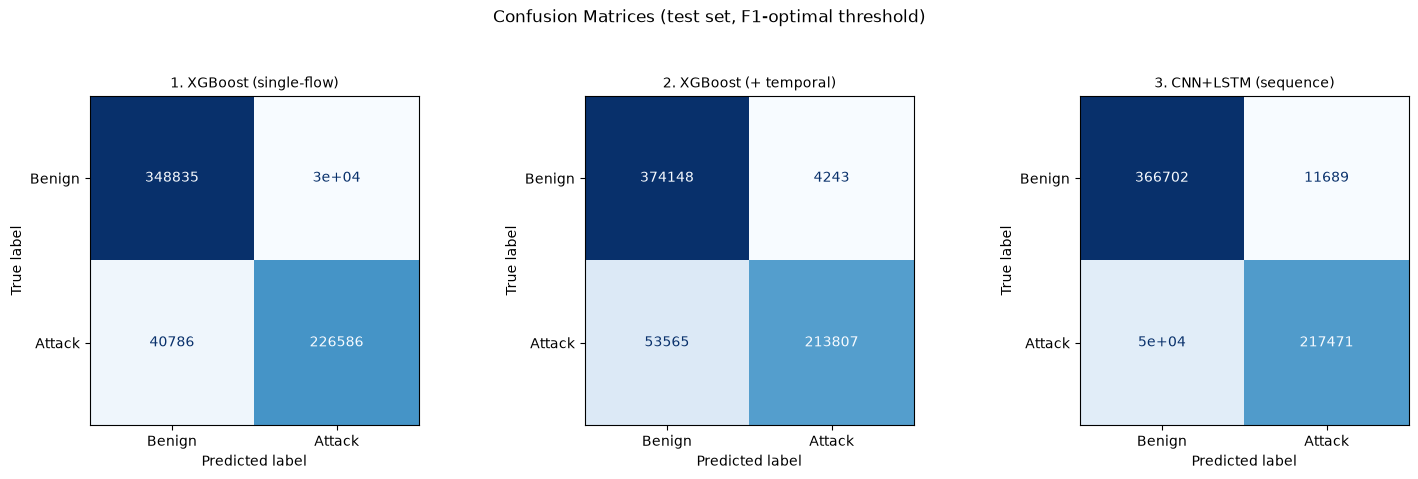

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name, yt, pred in zip(axes, variant_names, y_trues, preds_list):
    ConfusionMatrixDisplay.from_predictions(
        yt, pred, display_labels=["Benign", "Attack"], cmap="Blues", colorbar=False, ax=ax
    )
    ax.set_title(name, fontsize=10)
fig.suptitle("Confusion Matrices (test set, F1-optimal threshold)", y=1.05)
plt.tight_layout()
plt.show()

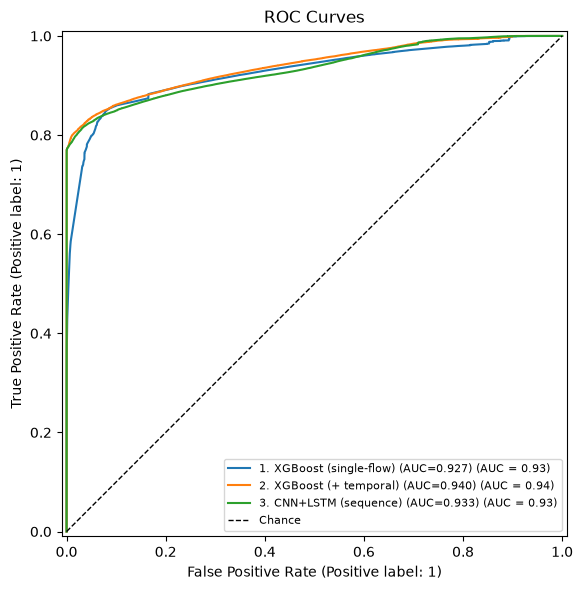

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, yt, probs in zip(variant_names, y_trues, all_probs):
    auc = roc_auc_score(yt, probs)
    RocCurveDisplay.from_predictions(yt, probs, name=f"{name} (AUC={auc:.3f})", ax=ax)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
ax.set_title("ROC Curves")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

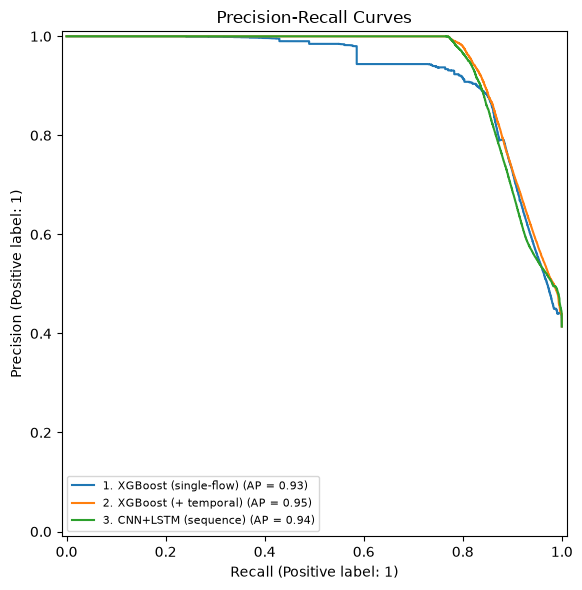

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, yt, probs in zip(variant_names, y_trues, all_probs):
    PrecisionRecallDisplay.from_predictions(yt, probs, name=name, ax=ax)
ax.set_title("Precision-Recall Curves")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

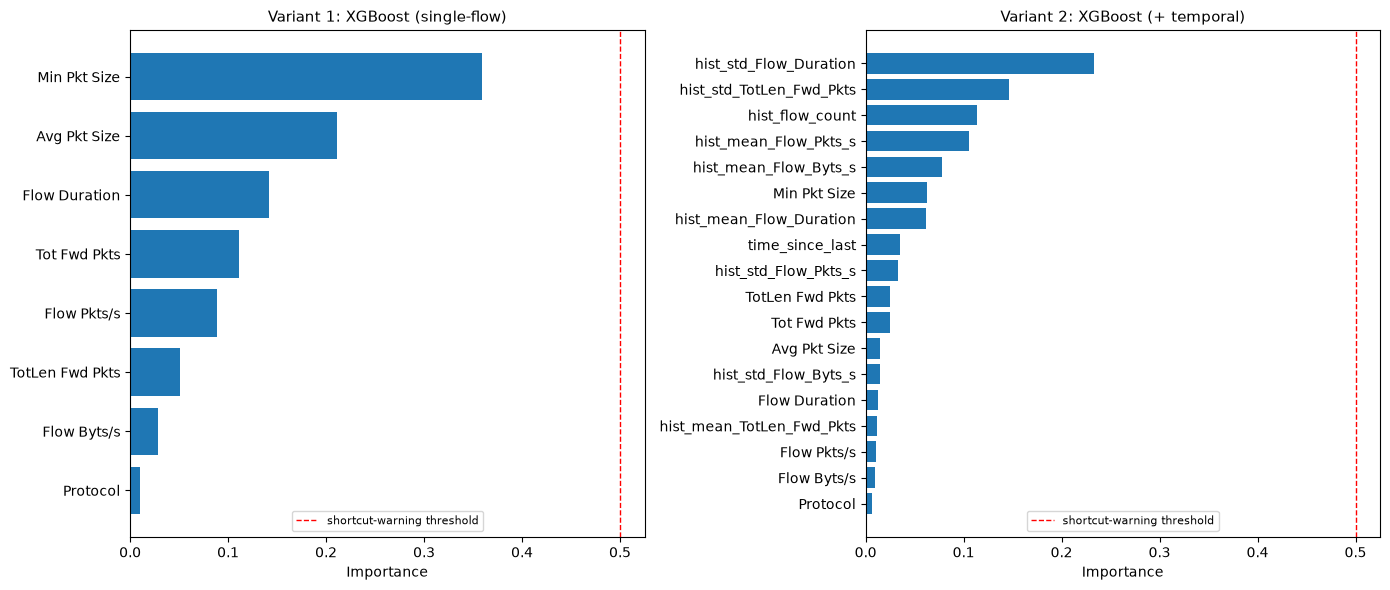

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, imp, title in [(axes[0], imp1, "Variant 1: XGBoost (single-flow)"), (axes[1], imp2, "Variant 2: XGBoost (+ temporal)")]:
    names = [n for n, _ in imp][::-1]
    values = [v for _, v in imp][::-1]
    colors = ["#d62728" if v > 0.5 else "#1f77b4" for v in values]
    ax.barh(names, values, color=colors)
    ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="shortcut-warning threshold")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Importance")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

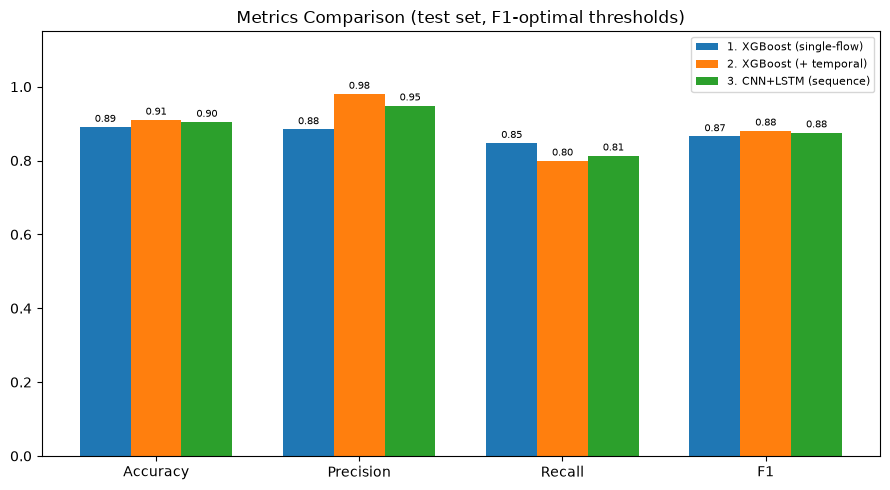

In [17]:
metric_names = ["accuracy", "precision", "recall", "f1"]
metrics_list = [m1, m2, m3]

x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, m) in enumerate(zip(variant_names, metrics_list)):
    values = [m[k] for k in metric_names]
    bars = ax.bar(x + (i - 1) * width, values, width, label=name)
    ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2)

ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metric_names])
ax.set_ylim(0, 1.15)
ax.set_title("Metrics Comparison (test set, F1-optimal thresholds)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

c:\Users\udaya\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


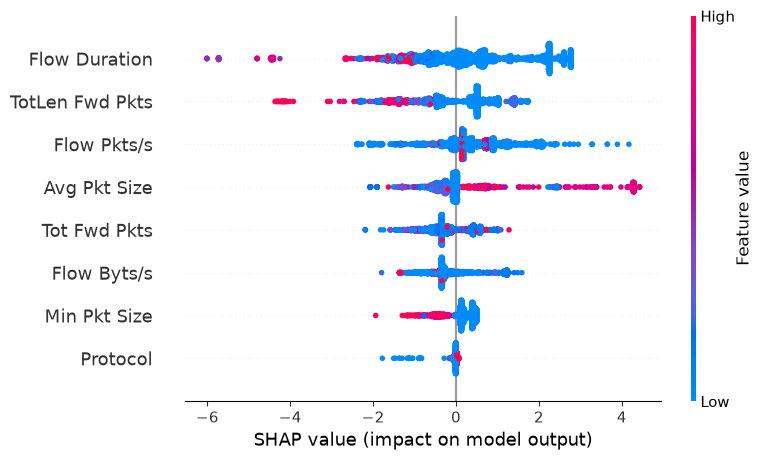

In [18]:
import shap

sample_idx = np.random.default_rng(0).choice(len(X1[test_mask]), size=min(2000, test_mask.sum()), replace=False)
X1_sample = X1[test_mask].iloc[sample_idx]

explainer = shap.TreeExplainer(xgb1)
shap_values = explainer.shap_values(X1_sample)

shap.summary_plot(shap_values, X1_sample, show=False)
plt.tight_layout()
plt.show()